In [3]:
!pip install linearmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, PooledOLS
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [linearmodels] [linearmodels]


In [4]:
# Penn World Tables 11.0 — GDP per capita and controls
pwt = pd.read_excel('pwt110.xlsx', sheet_name='Data')

# Target countries and their ISO3 codes
country_map = {
    'LAO': 'Lao PDR',
    'KHM': 'Cambodia',
    'PAK': 'Pakistan',
    'IND': 'India',
    'PHL': 'Philippines',
    'BGD': 'Bangladesh',
    'VNM': 'Vietnam',
    'THA': 'Thailand',
    'IDN': 'Indonesia',
    'MYS': 'Malaysia',
    'MMR': 'Myanmar',
    'TWN': 'Taiwan',
    'JPN': 'Japan',
    'KOR': 'South Korea',
    'CHN': 'China'
}

pwt_f = pwt[
    (pwt['countrycode'].isin(country_map.keys())) &
    (pwt['year'].between(2000, 2023))
].copy()

# GDP per capita: rgdpe (millions 2017 USD PPP) / pop (millions) = USD PPP per person
pwt_f['gdp_pc']    = pwt_f['rgdpe'] / pwt_f['pop']
pwt_f['ln_gdp_pc'] = np.log(pwt_f['gdp_pc'])

# Trade openness: exports share + abs(imports share)
pwt_f['trade']   = pwt_f['csh_x'] + pwt_f['csh_m'].abs()

# Gross capital formation share of GDP
pwt_f['capform'] = pwt_f['csh_i']

pwt_clean = pwt_f[['countrycode','year','ln_gdp_pc','gdp_pc','hc','trade','capform','pop']].copy()
pwt_clean = pwt_clean.rename(columns={'countrycode': 'iso3'})

print(f"PWT rows: {len(pwt_clean)}")
print(f"Countries: {pwt_clean['iso3'].nunique()}, Years: {pwt_clean['year'].nunique()}")
print("\nMissing values:")
print(pwt_clean.isnull().sum())
pwt_clean.head()

PWT rows: 360
Countries: 15, Years: 24

Missing values:
iso3         0
year         0
ln_gdp_pc    0
gdp_pc       0
hc           0
trade        0
capform      0
pop          0
dtype: int64


,iso3,year,ln_gdp_pc,gdp_pc,hc,trade,capform,pop
1160,BGD,2000,7.349734,1555.782835,1.639889,0.150221,0.207404,134.544304
1161,BGD,2001,7.358022,1568.730318,1.661910,0.157399,0.210769,136.805810
1162,BGD,2002,7.383912,1609.875489,1.684226,0.160139,0.214708,138.933658
1163,BGD,2003,7.399958,1635.915249,1.706841,0.163637,0.218853,140.970351
1164,BGD,2004,7.417470,1664.815397,1.724663,0.177964,0.227815,142.902856


In [5]:
# ITU DataHub CSV — long format, one row per country-year
internet_raw = pd.read_csv('internet_usage.csv', encoding='utf-8-sig')

# Confirm columns (should include: entityIso, entityName, dataValue, dataYear)
print("Columns:", internet_raw.columns.tolist())

# Filter to our 15 countries and years 2000–2023
internet = internet_raw[
    (internet_raw['entityIso'].isin(country_map.keys())) &
    (internet_raw['dataYear'].between(2000, 2023))
].copy()

internet['dataValue'] = pd.to_numeric(internet['dataValue'], errors='coerce')

internet_clean = internet[['entityIso','dataYear','dataValue']].copy()
internet_clean = internet_clean.rename(columns={
    'entityIso':  'iso3',
    'dataYear':   'year',
    'dataValue':  'internet_pct'
})

print(f"\nITU rows: {len(internet_clean)}")
print(f"Countries found: {internet_clean['iso3'].nunique()}")
print("Countries:", sorted(internet_clean['iso3'].unique()))
print("\nMissing values:", internet_clean.isnull().sum().to_dict())
internet_clean.head()

Columns: ['seriesID', 'seriesCode', 'seriesName', 'seriesParent', 'seriesUnits', 'entityID', 'entityIso', 'entityName', 'dataValue', 'dataYear', 'dataNote', 'dataSource', 'seriesDescription']

ITU rows: 352
Countries found: 15
Countries: ['BGD', 'CHN', 'IDN', 'IND', 'JPN', 'KHM', 'KOR', 'LAO', 'MMR', 'MYS', 'PAK', 'PHL', 'THA', 'TWN', 'VNM']

Missing values: {'iso3': 0, 'year': 0, 'internet_pct': 0}


,iso3,year,internet_pct
523,BGD,2000,0.071039
524,BGD,2001,0.129808
525,BGD,2002,0.139920
526,BGD,2003,0.163878
527,BGD,2004,0.199036


In [6]:
# Merge PWT + ITU on country-year
df = pd.merge(pwt_clean, internet_clean, on=['iso3','year'], how='inner')

# Developed country dummy: Taiwan, Japan, South Korea, China
developed = ['TWN', 'JPN', 'KOR', 'CHN']
df['developed'] = df['iso3'].isin(developed).astype(int)

# Add country label for plotting
df['country'] = df['iso3'].map(country_map)

# Sort before lagging — essential for correct shift()
df = df.sort_values(['iso3','year']).reset_index(drop=True)

# Lagged internet (t-1): addresses reverse causality
df['internet_lag1'] = df.groupby('iso3')['internet_pct'].shift(1)

# Interaction term: lagged internet × developed dummy
df['internet_x_dev'] = df['internet_lag1'] * df['developed']

print(f"Final dataset: {df.shape[0]} rows, {df['iso3'].nunique()} countries")
print(f"\nRows per country:")
print(df.groupby('country')['year'].count().sort_values())
print(f"\nMissing values in key variables:")
print(df[['ln_gdp_pc','internet_lag1','hc','trade','capform']].isnull().sum())

Final dataset: 352 rows, 15 countries

Rows per country:
country
Pakistan       20
Myanmar        20
Bangladesh     24
Cambodia       24
Indonesia      24
Japan          24
China          24
India          24
Malaysia       24
Lao PDR        24
Philippines    24
South Korea    24
Taiwan         24
Thailand       24
Vietnam        24
Name: year, dtype: int64

Missing values in key variables:
ln_gdp_pc         0
internet_lag1    15
hc                0
trade             0
capform           0
dtype: int64


In [7]:
desc_vars = ['gdp_pc','internet_pct','hc','trade','capform']
desc_labels = {
    'gdp_pc':       'GDP per Capita (USD PPP)',
    'internet_pct': 'Internet Usage (% population)',
    'hc':           'Human Capital Index',
    'trade':        'Trade Openness (share of GDP)',
    'capform':      'Capital Formation (share of GDP)'
}

desc = df[desc_vars].describe().T.round(2)
desc.index = [desc_labels[v] for v in desc_vars]
print("=== Descriptive Statistics ===")
print(desc[['count','mean','std','min','25%','50%','75%','max']].to_string())

=== Descriptive Statistics ===
                                  count      mean       std      min      25%      50%       75%       max
GDP per Capita (USD PPP)          352.0  16017.01  16072.68  1294.10  4702.34  8000.17  22297.47  65004.35
Internet Usage (% population)     352.0     36.47     31.81     0.00     6.12    29.45     65.39     97.69
Human Capital Index               352.0      2.45      0.61     1.53     1.87     2.38      2.83      3.87
Trade Openness (share of GDP)     352.0      0.45      0.30     0.09     0.20     0.37      0.62      1.22
Capital Formation (share of GDP)  352.0      0.26      0.07     0.10     0.22     0.25      0.30      0.47


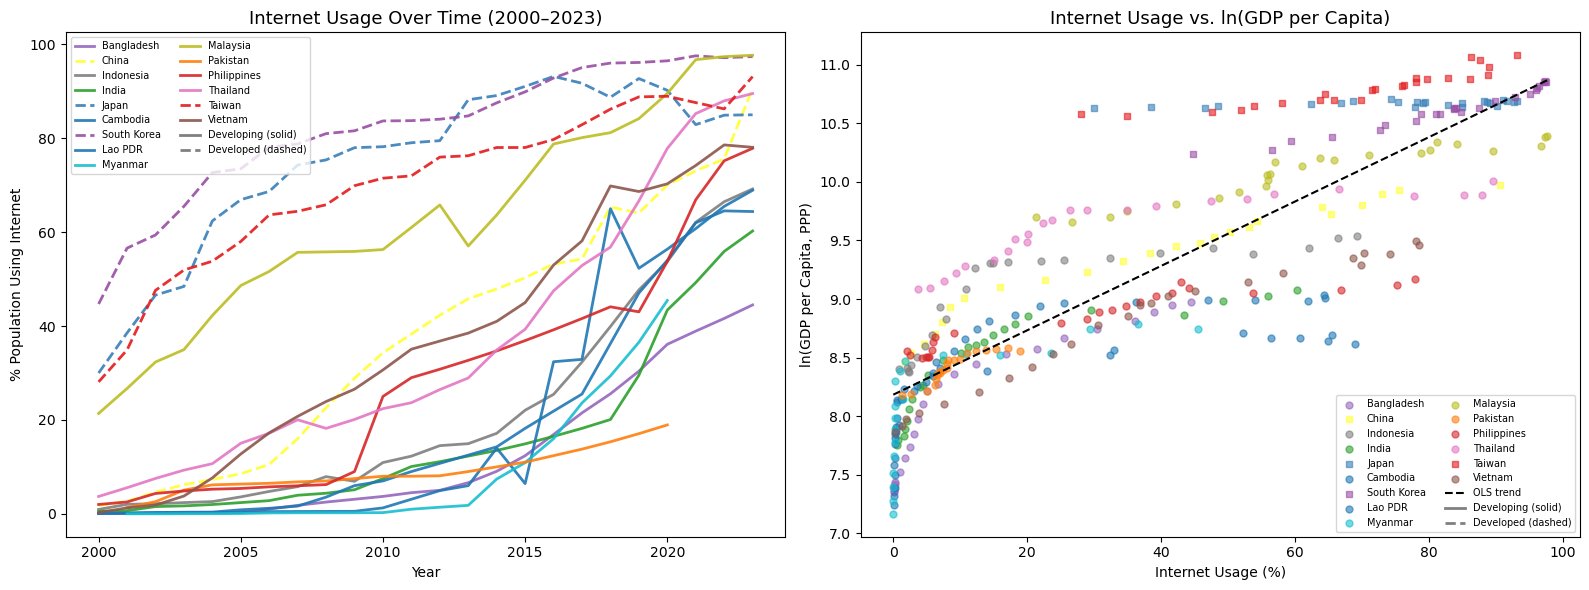

In [18]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import numpy as np

# Unique color per country using two colormaps
developing_isos = ['LAO','KHM','PAK','IND','PHL','BGD','VNM','THA','IDN','MYS','MMR']
developed_isos  = ['TWN','JPN','KOR','CHN']

dev_colors  = cm.tab10(np.linspace(0, 0.95, len(developing_isos)))
devd_colors = cm.Set1(np.linspace(0, 0.6, len(developed_isos)))

color_map = {}
for i, iso in enumerate(developing_isos):
    color_map[iso] = dev_colors[i]
for i, iso in enumerate(developed_isos):
    color_map[iso] = devd_colors[i]

# Line style: solid = developing, dashed = developed
style_map = {iso: '-'  for iso in developing_isos}
style_map.update({iso: '--' for iso in developed_isos})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Internet usage over time ---
for iso, grp in df.groupby('iso3'):
    axes[0].plot(grp['year'], grp['internet_pct'],
                 label=country_map[iso],
                 color=color_map[iso],
                 linestyle=style_map[iso],
                 linewidth=2, alpha=0.9)

axes[0].set_title('Internet Usage Over Time (2000–2023)', fontsize=13)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('% Population Using Internet')
axes[0].legend(fontsize=7.5, ncol=2, loc='upper left')

# --- Plot 2: Internet vs ln(GDP per Capita) scatter ---
for iso, grp in df.groupby('iso3'):
    axes[1].scatter(grp['internet_pct'], grp['ln_gdp_pc'],
                    label=country_map[iso],
                    color=color_map[iso],
                    marker='o' if iso in developing_isos else 's',
                    alpha=0.6, s=25)

# OLS trendline
valid = df[['internet_pct','ln_gdp_pc']].dropna()
m, b = np.polyfit(valid['internet_pct'], valid['ln_gdp_pc'], 1)
x_line = np.linspace(valid['internet_pct'].min(), valid['internet_pct'].max(), 100)
axes[1].plot(x_line, m*x_line + b, 'k--', linewidth=1.5, label='OLS trend')

axes[1].set_title('Internet Usage vs. ln(GDP per Capita)', fontsize=13)
axes[1].set_xlabel('Internet Usage (%)')
axes[1].set_ylabel('ln(GDP per Capita, PPP)')
axes[1].legend(fontsize=7.5, ncol=2, loc='lower right')

# Shared legend explaining line style / marker convention
legend_elements = [
    Line2D([0],[0], color='gray', linestyle='-',  lw=2, label='Developing (solid / circle)'),
    Line2D([0],[0], color='gray', linestyle='--', lw=2, label='Developed  (dashed / square)')
]
for ax in axes:
    existing = ax.get_legend()
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + legend_elements,
              labels=labels + ['Developing (solid)', 'Developed (dashed)'],
              fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('eda_internet_gdp.png', dpi=150, bbox_inches='tight')
plt.show()

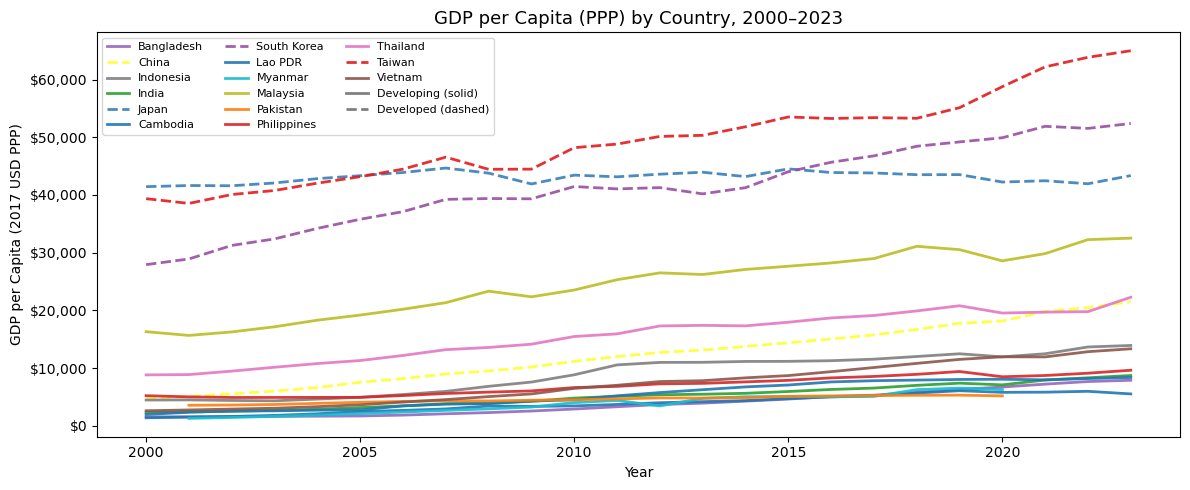

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

for iso, grp in df.groupby('iso3'):
    ax.plot(grp['year'], grp['gdp_pc'],
            label=country_map[iso],
            color=color_map[iso],
            linestyle=style_map[iso],
            linewidth=2, alpha=0.9)

ax.set_title('GDP per Capita (PPP) by Country, 2000–2023', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('GDP per Capita (2017 USD PPP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=8, ncol=3)

# Convention note
legend_elements = [
    Line2D([0],[0], color='gray', linestyle='-',  lw=2, label='Developing (solid)'),
    Line2D([0],[0], color='gray', linestyle='--', lw=2, label='Developed (dashed)')
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + legend_elements,
          labels=labels + ['Developing (solid)', 'Developed (dashed)'],
          fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig('gdp_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Drop rows missing any key variable
reg_vars = ['ln_gdp_pc','internet_lag1','hc','trade','capform','developed','internet_x_dev']
df_reg = df.dropna(subset=reg_vars).copy()

# Set MultiIndex required by linearmodels (entity, time)
df_reg = df_reg.set_index(['iso3','year'])

print(f"Regression sample: {len(df_reg)} obs, {df_reg.index.get_level_values('iso3').nunique()} countries")
print(f"Year range: {df_reg.index.get_level_values('year').min()}–{df_reg.index.get_level_values('year').max()}")

Regression sample: 337 obs, 15 countries
Year range: 2001–2023


In [11]:
# Pooled OLS ignores panel structure — useful as a naive baseline
X_pool = sm.add_constant(df_reg[['internet_lag1','hc','trade','capform']])
pooled = PooledOLS(df_reg['ln_gdp_pc'], X_pool).fit(cov_type='robust')

print("=" * 60)
print("MODEL 1: POOLED OLS (Baseline — no fixed effects)")
print("=" * 60)
print(pooled.summary)

MODEL 1: POOLED OLS (Baseline — no fixed effects)
                          PooledOLS Estimation Summary                          
Dep. Variable:              ln_gdp_pc   R-squared:                        0.8970
Estimator:                  PooledOLS   R-squared (Between):              0.9281
No. Observations:                 337   R-squared (Within):               0.6901
Date:                Sat, Mar 28 2026   R-squared (Overall):              0.8970
Time:                        20:28:59   Log-likelihood                   -92.653
Cov. Estimator:                Robust                                           
                                        F-statistic:                      722.71
Entities:                          15   P-value                           0.0000
Avg Obs:                       22.467   Distribution:                   F(4,332)
Min Obs:                       19.000                                           
Max Obs:                       23.000   F-statistic (robust

In [12]:
# Country FE (absorbs geography, institutions) + Year FE (absorbs global shocks)
fe_main = PanelOLS(
    df_reg['ln_gdp_pc'],
    df_reg[['internet_lag1','hc','trade','capform']],
    entity_effects=True,
    time_effects=True
).fit(cov_type='clustered', cluster_entity=True)  # Cluster SEs by country

print("=" * 60)
print("MODEL 2: TWO-WAY FIXED EFFECTS (Country + Year FEs)")
print("Clustered SEs by country")
print("=" * 60)
print(fe_main.summary)

MODEL 2: TWO-WAY FIXED EFFECTS (Country + Year FEs)
Clustered SEs by country
                          PanelOLS Estimation Summary                           
Dep. Variable:              ln_gdp_pc   R-squared:                        0.2191
Estimator:                   PanelOLS   R-squared (Between):              0.3258
No. Observations:                 337   R-squared (Within):               0.4388
Date:                Sat, Mar 28 2026   R-squared (Overall):              0.3275
Time:                        20:29:08   Log-likelihood                    170.48
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      20.760
Entities:                          15   P-value                           0.0000
Avg Obs:                       22.467   Distribution:                   F(4,296)
Min Obs:                       19.000                                           
Max Obs:                       2

In [14]:
# MODEL 3: FE with Developed/Developing Interaction
# NOTE: 'developed' dummy is dropped — it is time-invariant and is fully
# absorbed by country fixed effects. Only the interaction term is needed.

fe_interact = PanelOLS(
    df_reg['ln_gdp_pc'],
    df_reg[['internet_lag1', 'internet_x_dev', 'hc', 'trade', 'capform']],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True      # Silently drops any remaining collinear variables
).fit(cov_type='clustered', cluster_entity=True)

print("=" * 60)
print("MODEL 3: FE WITH DEVELOPING/DEVELOPED INTERACTION")
print("(Developed dummy dropped — absorbed by country FEs)")
print("=" * 60)
print(fe_interact.summary)

# Interpret coefficients
b1  = fe_interact.params['internet_lag1']
b3  = fe_interact.params['internet_x_dev']
se1 = fe_interact.std_errors['internet_lag1']
se3 = fe_interact.std_errors['internet_x_dev']

print("\n--- Interpretation ---")
print(f"Effect for DEVELOPING countries (β₁):           {b1:.5f}  (SE: {se1:.5f})")
print(f"Additional effect for DEVELOPED countries (β₃): {b3:.5f}  (SE: {se3:.5f})")
print(f"Total effect for DEVELOPED countries (β₁ + β₃): {b1 + b3:.5f}")
print(f"\nA 1 pp rise in internet usage is associated with:")
print(f"  Developing: {b1*100:.3f}% change in GDP per capita")
print(f"  Developed:  {(b1+b3)*100:.3f}% change in GDP per capita")

MODEL 3: FE WITH DEVELOPING/DEVELOPED INTERACTION
(Developed dummy dropped — absorbed by country FEs)
                          PanelOLS Estimation Summary                           
Dep. Variable:              ln_gdp_pc   R-squared:                        0.3818
Estimator:                   PanelOLS   R-squared (Between):              0.3682
No. Observations:                 337   R-squared (Within):               0.4920
Date:                Sat, Mar 28 2026   R-squared (Overall):              0.3697
Time:                        20:31:00   Log-likelihood                    209.86
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      36.445
Entities:                          15   P-value                           0.0000
Avg Obs:                       22.467   Distribution:                   F(5,295)
Min Obs:                       19.000                                           
Max Obs

In [16]:
def fmt(params, pvalues, key):
    """Format coefficient with significance star, or return '—' if not in model."""
    if key not in params:
        return '—'
    stars = '*' * int(pvalues[key] < 0.05)
    return f"{params[key]:.4f}{stars}"

results_data = {
    'Variable': [
        'Internet (lag 1)', 'Human Capital', 'Trade Openness',
        'Capital Formation', 'Developed (dummy)', 'Internet × Developed'
    ],
    'Pooled OLS': [
        fmt(pooled.params, pooled.pvalues, 'internet_lag1'),
        fmt(pooled.params, pooled.pvalues, 'hc'),
        fmt(pooled.params, pooled.pvalues, 'trade'),
        fmt(pooled.params, pooled.pvalues, 'capform'),
        '—', '—'
    ],
    'Two-Way FE': [
        fmt(fe_main.params, fe_main.pvalues, 'internet_lag1'),
        fmt(fe_main.params, fe_main.pvalues, 'hc'),
        fmt(fe_main.params, fe_main.pvalues, 'trade'),
        fmt(fe_main.params, fe_main.pvalues, 'capform'),
        '—', '—'
    ],
    'FE + Interaction': [
        fmt(fe_interact.params, fe_interact.pvalues, 'internet_lag1'),
        fmt(fe_interact.params, fe_interact.pvalues, 'hc'),
        fmt(fe_interact.params, fe_interact.pvalues, 'trade'),
        fmt(fe_interact.params, fe_interact.pvalues, 'capform'),
        '— (absorbed by country FEs)',          # time-invariant, absorbed
        fmt(fe_interact.params, fe_interact.pvalues, 'internet_x_dev')
    ]
}

results_df = pd.DataFrame(results_data)
print("=== REGRESSION RESULTS SUMMARY ===")
print("Dependent variable: ln(GDP per Capita, PPP)")
print("* = significant at 5% level")
print()
print(results_df.to_string(index=False))
results_df.to_csv('regression_results.csv', index=False)
print("\nSaved to regression_results.csv")

=== REGRESSION RESULTS SUMMARY ===
Dependent variable: ln(GDP per Capita, PPP)
* = significant at 5% level

            Variable Pooled OLS Two-Way FE            FE + Interaction
    Internet (lag 1)    0.0073*     0.0008                      0.0024
       Human Capital    1.0504*     0.3723                      0.5016
      Trade Openness    0.3984*     0.0786                      0.1382
   Capital Formation    0.5177*    2.5497*                     2.5362*
   Developed (dummy)          —          — — (absorbed by country FEs)
Internet × Developed          —          —                     -0.0082

Saved to regression_results.csv
